[2026-07-24 17:37:19] [info     ] 计算分数 (仅加载权重推理, 不重训)            end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-24 17:37:21] [info     ] 已加载模型                          device=cuda path=/home/aiuser/work/transformer_model072505.json
[2026-07-24 17:37:21] [info     ] 分块构建测试集并预测                     end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-24 17:37:29] [info     ] 推理分块完成                         chunk=1/25 cum_rows=12098
[2026-07-24 17:37:36] [info     ] 推理分块完成                         chunk=2/25 cum_rows=24187
[2026-07-24 17:37:44] [info     ] 推理分块完成                         chunk=3/25 cum_rows=36105
[2026-07-24 17:37:52] [info     ] 推理分块完成                         chunk=4/25 cum_rows=48205
[2026-07-24 17:38:00] [info     ] 推理分块完成                         chunk=5/25 cum_rows=60288
[2026-07-24 17:38:08] [info     ] 推理分块完成                         chunk=6/25 cum_rows=72380
[2026-07-24 17:38:16] [info     ] 推理分块完成                         chunk=7/25 cum_rows=84

时段,IC
2024-01-15~2024-02-08,-0.0197
2024-09-24~2024-10-08,0.0218

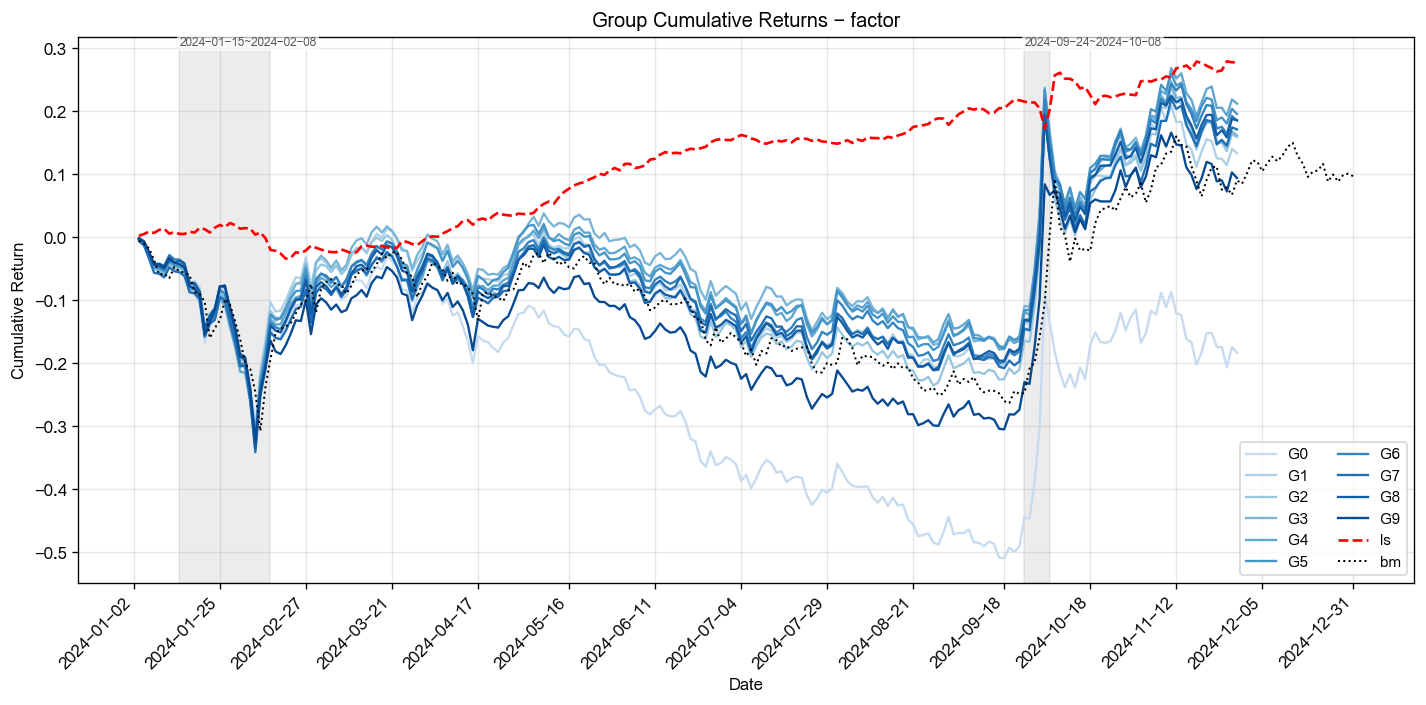
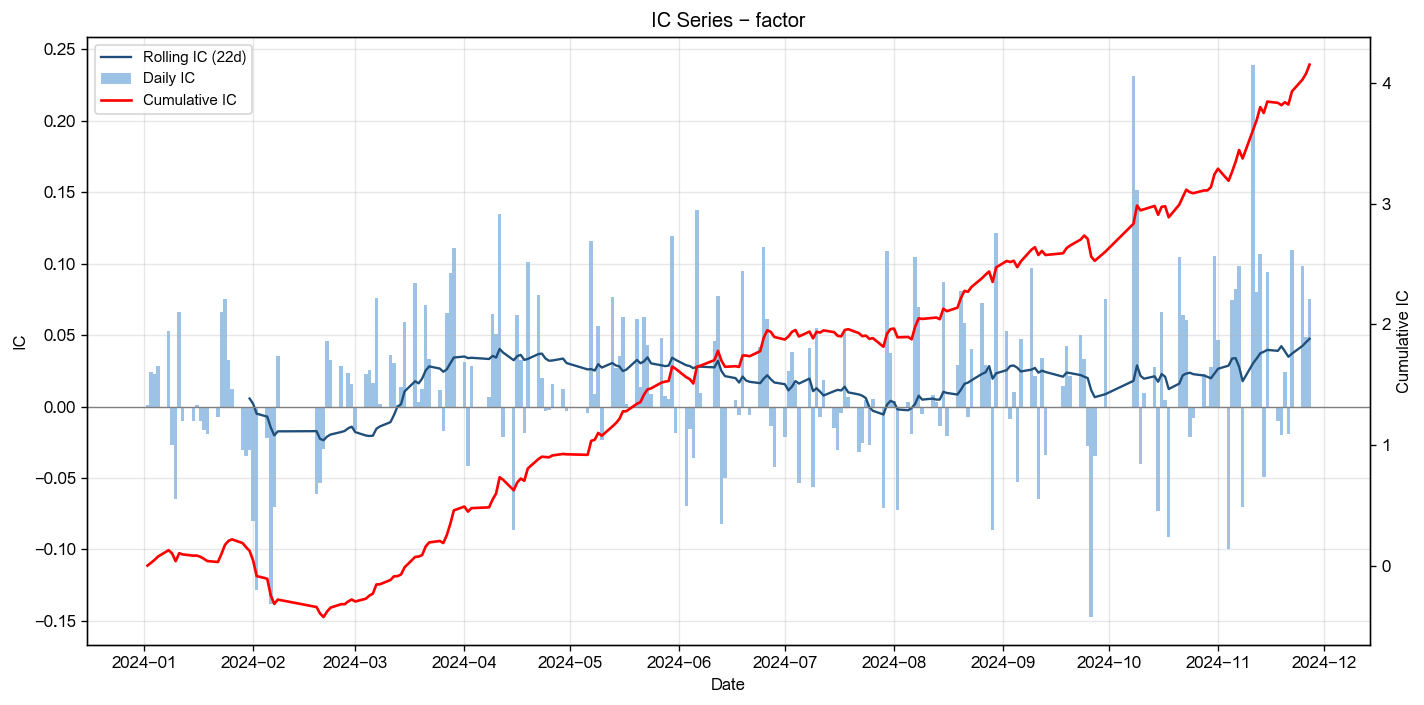
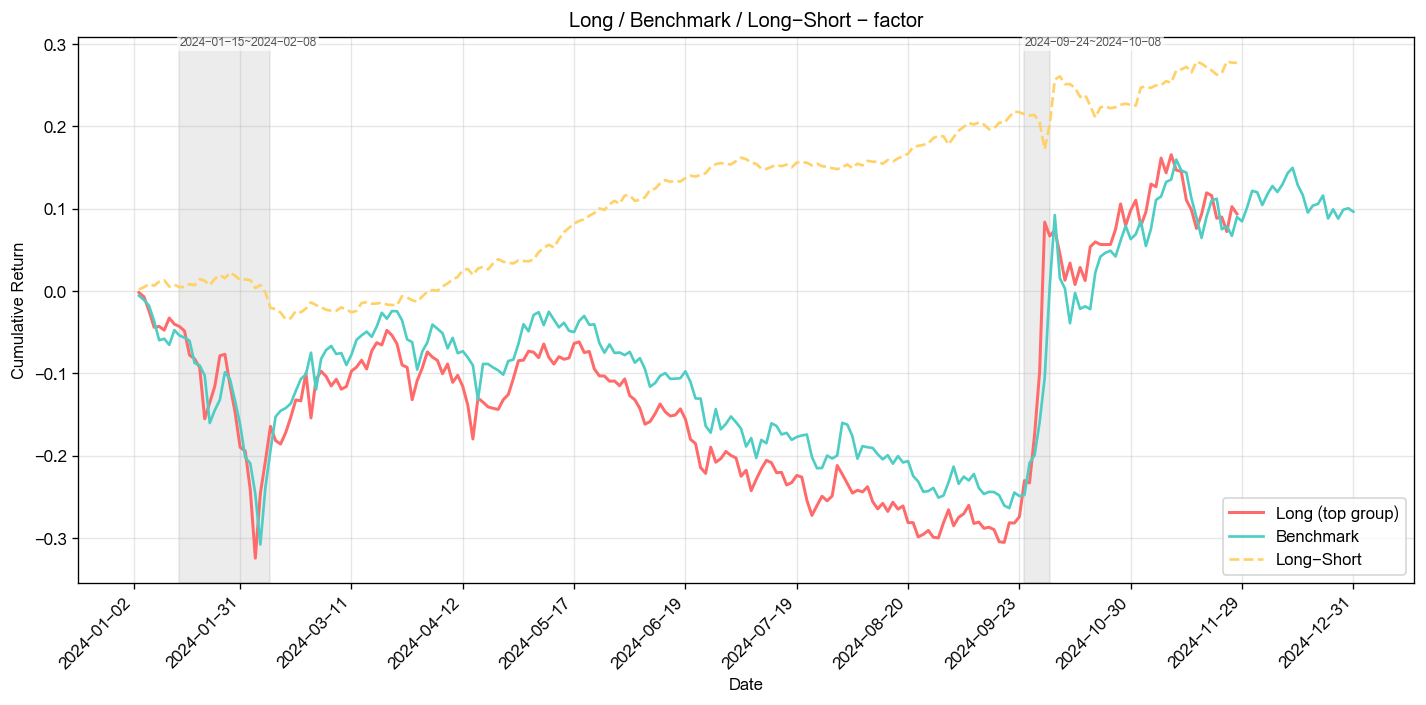
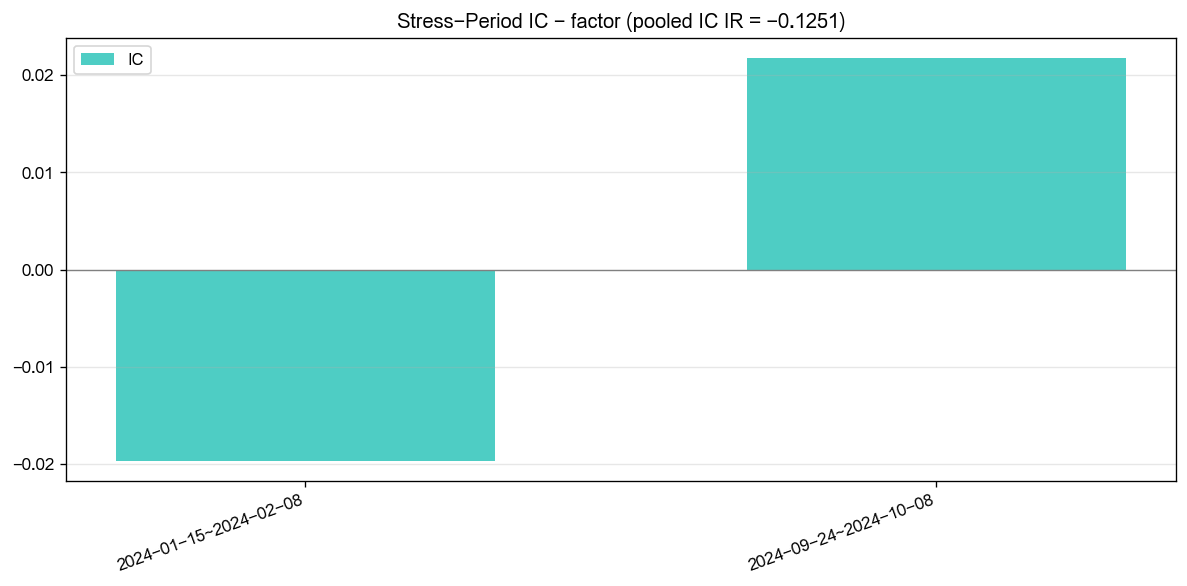
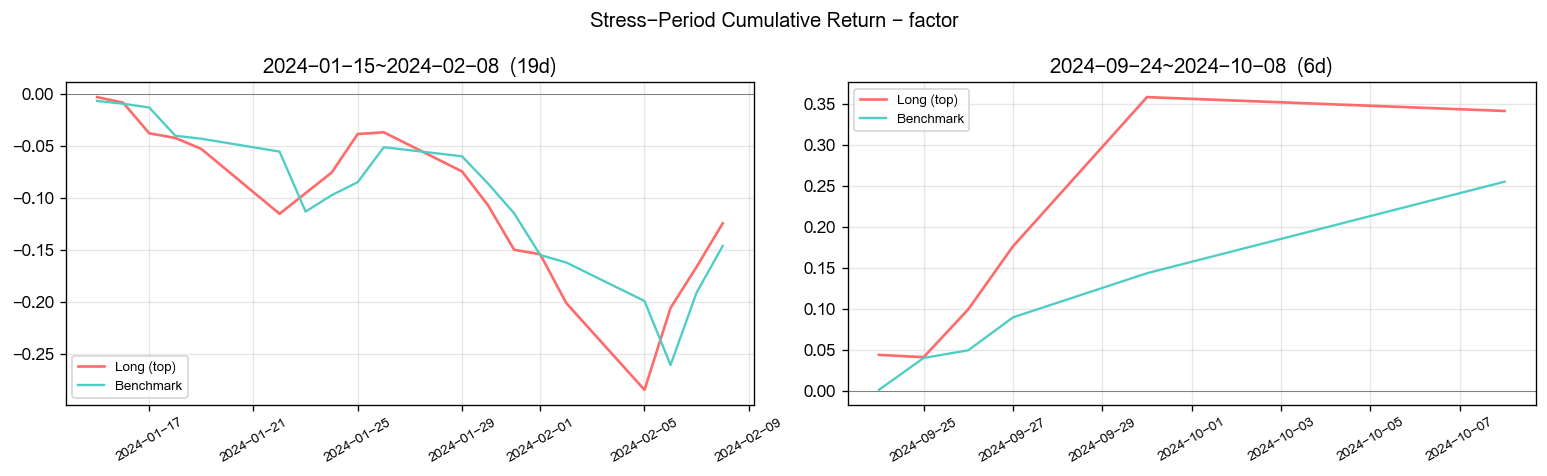

[2026-07-24 17:40:59] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-24 17:40:59] [warning  ] 返回的Outputs实例(size=35375893) 大于 64K, 将不会被缓存
[2026-07-24 17:40:59] [info     ] bigalpha_eval.v4 运行完成 [22.464s].


In [1]:
"""
# Transformer 端到端 demo —— 分块读取推理 (防止读数据时内存溢出)

本 notebook 与「Transformer预训练」目录下的推理 notebook 作用相同: 加载
`transformer_train.py` 产出的 `transformer_model.json`, 在平台注入的**测试集区间**上打分。

**唯一区别在取数**: 原版 `build_dataset` 会把整个测试区间、全体中证 1000 成分股 (约 1200 只)
的 1 分钟原始 K 线一次性 `dai.query(...).df()` 到内存, 提交到平台跑推理时经常内存溢出 (OOM)。
本版改用 `transformer_train.predict_scores`: **按股票分批查询, 每批 查数→切窗口→预测,
只保留 (date, instrument, score) 三列结果, 原始行当批释放**, 峰值内存只与 `CHUNK_SIZE` 有关,
与测试区间长度、股票总数无关。这才是提交后最需要省内存的路径。

> 为什么按股票分批而不是按日期? 回看窗口 (SEQ_LEN 根 bar) 需要单只股票时间连续,
> 按日期切会让窗口跨越边界而损坏; 按股票切则每只股票历史完整、互不影响。

提交时请把 `transformer_train.py` 与训练好的 `transformer_model.json` 随本 notebook 一并上传。
公榜阶段平台只替换 `datasources / start_date / end_date` 并调用 `main`;
私榜阶段平台用 `train_and_save` 在隔离环境从零重训 (训练侧同样已分块, 不会 OOM)。
"""

# ==== 从训练侧脚本导入共享定义 (配置 / 模型结构 / 数据构建 / 分块推理) ====
import os

import numpy as np
import pandas as pd
import dai
import torch
import structlog

from train_0724 import (
    MODEL_PATH,
    StockTransformer, pool, predict_scores, train_and_save, load_model,
)

logger = structlog.get_logger()


# ==== 加载权重做推理 (平台公榜阶段调用, 只替换 datasources/start_date/end_date) ====
def main(datasources, start_date, end_date):
    """加载已训练好的模型, 在样本外测试区间 (start_date~end_date) 上分块推理打分。

    本函数**不训练**: 权重来自随 notebook 上传的 MODEL_PATH 文件。
    取数走 predict_scores 分块进行, 避免一次性把全区间原始 1m 数据读进内存导致 OOM。
    输出每日分数 ['date','instrument','score']。"""
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}; 请先运行 train_and_save(...) 训练并保存, 再随 notebook 一起上传")

    # 模型存为文本类文件 (JSON), 用 load_model 读回 (张量按 dtype/shape 还原)
    ckpt = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(ckpt["mean"], np.float32), np.asarray(ckpt["std"], np.float32))
    model = StockTransformer(**ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("已加载模型", path=MODEL_PATH, device=str(device))

    # ---------- 分块推理 (样本外测试区间, 峰值内存只与 CHUNK_SIZE 有关) ----------
    logger.info("分块构建测试集并预测", start=str(start_date), end=str(end_date))
    idx_df = predict_scores(model, table, start_date, end_date,
                            pool(start_date, end_date), stats, device)

    # ---------- 对齐中证 1000 + 规范输出 ----------
    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                    filters={"date": [start_date, end_date]}).df()
    result = (pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
                .replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])
                .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
                .reset_index(drop=True))
    logger.info("分数构建完成", rows=len(result), days=result["date"].nunique(),
                instruments=result["instrument"].nunique())
    return result

if __name__ == "__main__":
    from bigmodule import M

    # 只用 1 分钟 K 线作为输入数据
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    # 本地首次运行: 若权重文件不存在, 先训练并保存 (上传前请确保已生成 transformer_model.json)
    # 正式做法是在终端执行 `python transformer_train.py` 训练一次, 这里仅为本地便捷兜底
    if not os.path.exists(MODEL_PATH):
        logger.info("未发现已保存模型, 开始训练", path=MODEL_PATH)
        train_and_save(datasources)

    # 本地用一小段区间模拟「平台注入的测试集区间」(训练区间已在 transformer_train.py 内写死)
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("计算分数 (仅加载权重推理, 不重训)", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    # 评估系统: 分数经风格剔除后等价于每日单因子, show=True 画绩效图 (IC / 分组 / 压力期)
    logger.info("开始评估分数")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
